<a href="https://colab.research.google.com/github/duazia358/DecodeLabs-Internship/blob/main/notebooks/Project_4_Image_Text_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Set Up Project Files & Dependencies

In [1]:
pip install opencv-python pytesseract pillow matplotlib

In [2]:
!apt-get update
!apt-get install -y tesseract-ocr

Get:1 https://cli.github.com/packages stable InRelease [4,685 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [113 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.8 MB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,191 kB]
Get:14 https://ppa.launchp

Step 2: Pre-Processing Pipeline & Image Upload

Please upload a sample image containing text:


Saving images (1).jpg to images (1).jpg


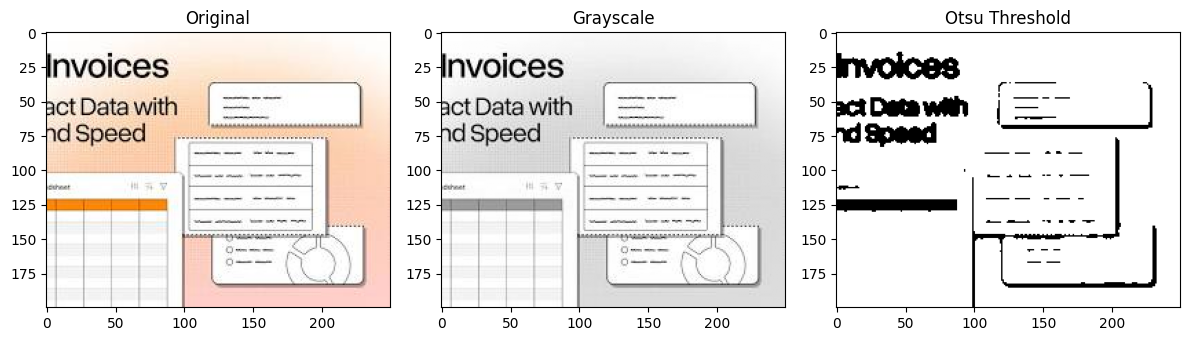

In [3]:
import cv2
import pytesseract
from pytesseract import Output
import matplotlib.pyplot as plt
from google.colab import files

# 1. Upload sample image to Colab
print("Please upload a sample image containing text:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# 2. Pre-processing Function (Grayscale + Blur + Otsu's Thresholding)
def preprocess_image(path):
    image = cv2.imread(path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresholded = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return image, gray, thresholded

# Load and process
original_img, gray_img, thresh_img = preprocess_image(image_path)

# Display pre-processing stages
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)); plt.title("Original")
plt.subplot(1, 3, 2); plt.imshow(gray_img, cmap='gray'); plt.title("Grayscale")
plt.subplot(1, 3, 3); plt.imshow(thresh_img, cmap='gray'); plt.title("Otsu Threshold")
plt.tight_layout()
plt.show()

Step 3: OCR Extraction & 80% Confidence Filter

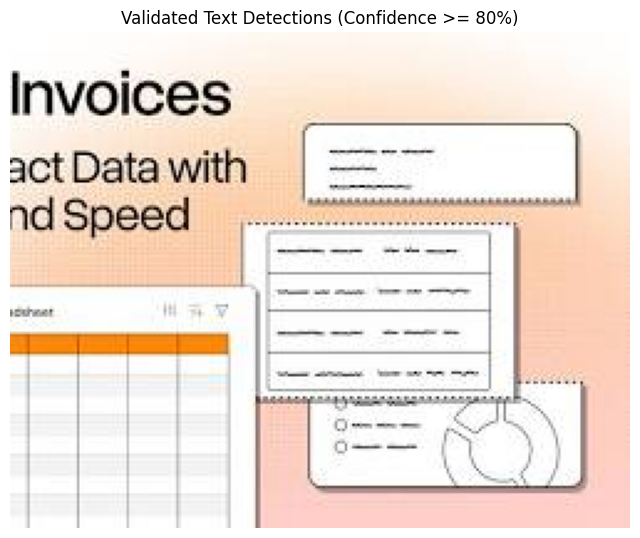


--- EXTRACTED TEXT OUTPUT ---
No text met the 80% confidence threshold.


In [4]:
# 1. Extract text and bounding box data using PyTesseract
data = pytesseract.image_to_data(thresh_img, config='--psm 3', output_type=Output.DICT)

annotated_img = original_img.copy()
extracted_text_blocks = []
CONFIDENCE_THRESHOLD = 80.0

# 2. Iterate through detections and apply the 80% Confidence Gatekeeper
n_boxes = len(data['text'])
for i in range(n_boxes):
    text = data['text'][i].strip()
    conf = float(data['conf'][i])

    # Filter for valid text and confidence >= 80%
    if conf >= CONFIDENCE_THRESHOLD and text != "":
        x, y, w, h = data['left'][i], data['top'][i], data['width'][i], data['height'][i]
        extracted_text_blocks.append(text)

        # Draw bounding box and confidence label
        cv2.rectangle(annotated_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(annotated_img, f"{text} ({int(conf)}%)", (x, y - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

# 3. Save extracted output locally
full_extracted_text = " ".join(extracted_text_blocks)
with open("extracted_text.txt", "w") as f:
    f.write(full_extracted_text)

# 4. Display annotated visual output
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
plt.title(f"Validated Text Detections (Confidence >= {int(CONFIDENCE_THRESHOLD)}%)")
plt.axis('off')
plt.show()

print("\n--- EXTRACTED TEXT OUTPUT ---")
print(full_extracted_text if full_extracted_text else "No text met the 80% confidence threshold.")